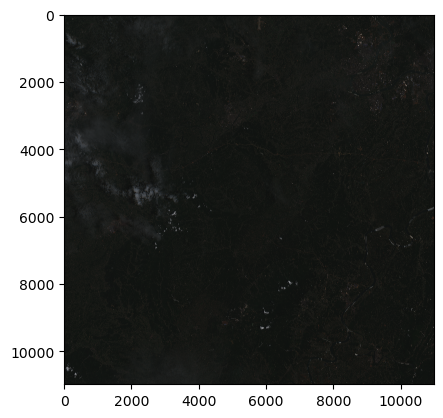

In [2]:
from osgeo import gdal
from matplotlib import pyplot as plt
gdal.UseExceptions()
data_path=("/mnt/d/pyLearn/pyLearn/test_project/data/tif/"
        "S2B_MSIL2A_20230611T030529_N0509_R075_T49RFL_20230611T053545_10m_7bands.tif")
with gdal.Open(data_path) as src:
     band=src.ReadAsArray()

rgb=band[[2,1,0],:,:] # 选择需要的波段，注意波段索引可能需要调整
img=rgb.transpose(1,2,0) # 将波段数据转换为图像格式，注意波段顺序可能需要调整
# 以rgb进行显示
# 对uint16类型的图像进行归一化处理
img = img.astype('float32') / band.max()  # 使用实际的最大值进行归一化
# 显示图像
plt.imshow(img)
plt.show()

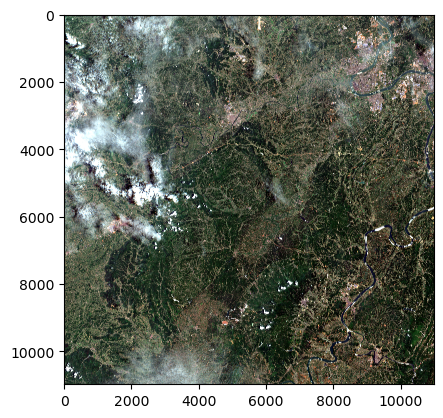

In [5]:
import numpy as np
from matplotlib import pyplot as plt

rgb = band[[2, 1, 0], :, :]  # B4,B3,B2
img = rgb.transpose(1, 2, 0).astype("float32")

# 2-98% 拉伸（逐通道）
for i in range(3):
    p2, p98 = np.percentile(img[:, :, i], (2, 98))
    img[:, :, i] = np.clip((img[:, :, i] - p2) / (p98 - p2), 0, 1)
gamma = 0.80  # 可以调整gamma值
img = np.power(img, gamma)  # 应用gamma校正
plt.imshow(img)
plt.show()

In [3]:
for i in range(4):
    print(i, band[i].min(), band[i].max())

0 0 20256
1 0 19056
2 0 18192
3 0 17233
